### Hypothesis: A subset of LTRs forms epigenetically dynamic chromatin hotspots, and these hotspots are preferentially remodeled in cancer.

##### 1. Cell-type-level hotspot fraction comparison

**1-1. What fraction of LTRs are hotspots?**

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../processed/ltr_feature_table.csv")
print(df.shape)
df.head()

(85363427, 28)


,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
# Define hotspot 
df["is_hotspot"] = df["n_transitions"] >= 4

In [4]:
# Compute fraction per cell type
summary_per_cell = (
    df.groupby("cell_id")
    .agg(
        hotspot_fraction=("is_hotspot", "mean"),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

print(summary_per_cell.head())

  cell_id  hotspot_fraction  is_cancer
0    E001          0.012507      False
1    E002          0.005469      False
2    E003          0.011782      False
3    E004          0.005829      False
4    E005          0.013506      False


In [5]:
# Label groups
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

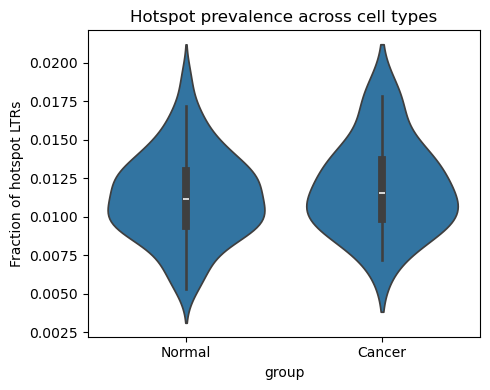

In [ ]:
# Quick visualization 

plt.figure(figsize=(5,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="hotspot_fraction",
    inner="box"
)

plt.ylabel("Fraction of hotspot LTRs")
plt.title("Hotspot prevalence across cell types")

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import mannwhitneyu

normal = summary_per_cell[summary_per_cell["group"]=="Normal"]["hotspot_fraction"]
cancer = summary_per_cell[summary_per_cell["group"]=="Cancer"]["hotspot_fraction"]

stat, p = mannwhitneyu(normal, cancer)

print("p-value:", p)

p-value: 0.4877743422013622


In [9]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].describe())

        count      mean       std       min       25%       50%       75%  \
group                                                                       
Cancer   16.0  0.011955  0.002900  0.007168  0.009841  0.011563  0.013704   
Normal  111.0  0.011333  0.002844  0.005337  0.009407  0.011162  0.012953   

             max  
group             
Cancer  0.017861  
Normal  0.018968  


In [10]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].mean())

group
Cancer    0.011955
Normal    0.011333
Name: hotspot_fraction, dtype: float64


##### For each LTR locus:
across all cell types:
 - how often is it hotspot?

In [11]:
ltr_variability = (
    df.groupby(["chrom", "start", "end", "name"])
    .agg(
        hotspot_freq=("is_hotspot", "mean"),
        n_celltypes=("is_hotspot", "size")
    )
    .reset_index()
)

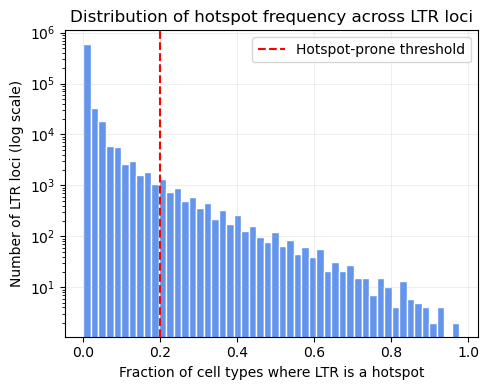

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

ltr_variability["hotspot_freq"].hist(
    bins=50,
    log=True,
    color="cornflowerblue",
    edgecolor="white"
)

plt.xlabel("Fraction of cell types where LTR is a hotspot")
plt.ylabel("Number of LTR loci (log scale)")
plt.title("Distribution of hotspot frequency across LTR loci")

plt.axvline(0.2, color="red", linestyle="--", label="Hotspot-prone threshold")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

**So...Hotspot behavior is not random—it is locus-specific and heterogeneous**

-  LTRs exhibit heterogeneous chromatin dynamics, where a subset of loci repeatedly forms transition hotspots across cell types. 
- These patterns are not captured by global or local statistical features, suggesting higher-order regulatory structure.

In [24]:
ltr_variability["is_hotspot_prone"] = ltr_variability["hotspot_freq"] > 0.2

In [25]:
df = df.merge(ltr_variability[["chrom","start","end","name","hotspot_freq"]],
              on=["chrom","start","end","name"])

# Define “hotspot-prone LTRs”
df["is_hotspot_prone"] = df["hotspot_freq"] > 0.2

In [16]:
df.groupby("is_hotspot_prone")["entropy"].mean()

is_hotspot_prone
False    0.183103
True     1.296051
Name: entropy, dtype: float64

In [38]:
# make it log scale
df["entropy_log"] = np.log10(df["entropy"] + 1e-3)

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_67753/551533082.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


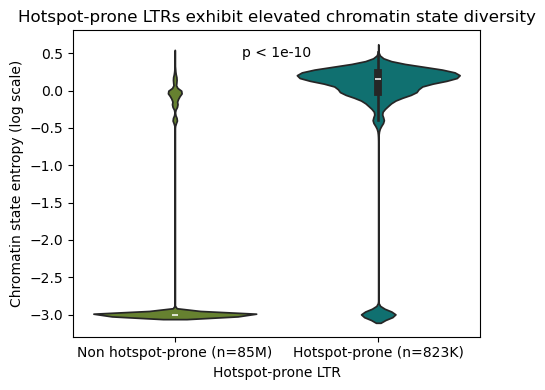

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

def format_n(n):
    if n >= 1_000_000:
        return f"{n/1_000_000:.0f}M"
    elif n >= 1_000:
        return f"{n/1_000:.0f}K"
    else:
        return str(n)

n_no = (df["is_hotspot_prone"] == False).sum()
n_yes = (df["is_hotspot_prone"] == True).sum()

palette = {
    "True": "teal",
    "False": "olivedrab"
}

plt.figure(figsize=(5,4))

sns.violinplot(
    data=df,
    x="is_hotspot_prone",
    y="entropy_log",
    palette=palette,
    inner="box"
)

plt.xlabel("Hotspot-prone LTR")
plt.ylabel("Chromatin state entropy (log scale)")
plt.title("Hotspot-prone LTRs exhibit elevated chromatin state diversity")

# plt.xticks([0,1], [f"Non hotspot-prone (n={n_no})", f"Hotspot-prone (n={n_yes})"])
plt.xticks(
    [0,1],
    [
        f"Non hotspot-prone (n={format_n(n_no)})",
        f"Hotspot-prone (n={format_n(n_yes)})"
    ]
)
plt.text(0.5, 0.45, "p < 1e-10", ha="center")

plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import mannwhitneyu

group1 = df[df["is_hotspot_prone"]==False]["entropy"]
group2 = df[df["is_hotspot_prone"]==True]["entropy"]

stat, p = mannwhitneyu(group1, group2)
print("p-value:", p)

p-value: 0.0


In [43]:
df[["n_transitions", "entropy"]].corr()

,n_transitions,entropy
n_transitions,1.000000,0.911908
entropy,0.911908,1.000000


<Axes: xlabel='n_transitions', ylabel='entropy'>

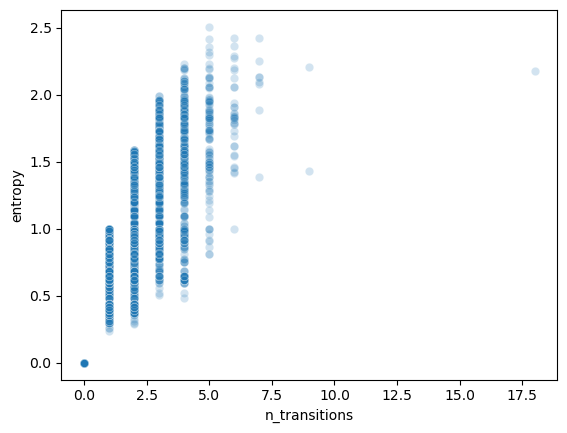

In [29]:
sns.scatterplot(
    data=df.sample(50000),
    x="n_transitions",
    y="entropy",
    alpha=0.2
)

In [32]:
df["entropy_norm"] = df["entropy"] / np.log(df["n_unique_states"].clip(lower=2))

In [33]:
df.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_L,frac_M,frac_N,frac_O,is_hotspot,hotspot_freq_x,is_hotspot_prone,hotspot_freq_y,hotspot_freq,entropy_norm
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0


##### 2. State/category enrichment in hotspot vs non-hotspot

##### 3. Three pairs: Do hotspot-prone LTRs undergo systematic remodeling during cancer transition?

In [47]:
import pandas as pd

df = pd.read_csv("../processed/ltr_feature_table.csv")
df["is_hotspot"] = df["n_transitions"] >= 4

In [48]:
df_pair = df[[
    "cell_id", "chrom", "start", "end", "name", "is_hotspot"
]].copy()

In [49]:
pairs = {
    "liver": ("E066", "E118"),
    "lung": ("E096", "E114"),
    "blood": ("E029", "E123"),
}

In [50]:
def make_hotspot_transition_table(df_pair, normal_id, cancer_id):
    df_normal = (
        df_pair[df_pair["cell_id"] == normal_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_normal"})
    )

    df_cancer = (
        df_pair[df_pair["cell_id"] == cancer_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_cancer"})
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    transition_table = pd.crosstab(
        merged["hotspot_normal"],
        merged["hotspot_cancer"]
    )

    transition_table.index = ["non-hotspot", "hotspot"]
    transition_table.columns = ["non-hotspot", "hotspot"]

    return merged, transition_table

In [51]:
merged_liver, table_liver = make_hotspot_transition_table(df_pair, "E066", "E118")
table_liver

,non-hotspot,hotspot
non-hotspot,654417,10267
hotspot,6085,1745


In [52]:
results = {}

for tissue, (normal_id, cancer_id) in pairs.items():
    merged, table = make_hotspot_transition_table(df_pair, normal_id, cancer_id)
    results[tissue] = {"merged": merged, "table": table}
    print(f"\n{tissue.upper()} ({normal_id} -> {cancer_id})")
    print(table)


LIVER (E066 -> E118)
             non-hotspot  hotspot
non-hotspot       654417    10267
hotspot             6085     1745

LUNG (E096 -> E114)
             non-hotspot  hotspot
non-hotspot       657114     8561
hotspot             6147      695

BLOOD (E029 -> E123)
             non-hotspot  hotspot
non-hotspot       650998     7139
hotspot             5669      849


In [53]:
# Row-normalized
for tissue in results:
    table = results[tissue]["table"]
    prop = table.div(table.sum(axis=1), axis=0)
    results[tissue]["prop_row"] = prop

    print(f"\n{tissue.upper()} row-normalized")
    print(prop)


LIVER row-normalized
             non-hotspot   hotspot
non-hotspot     0.984554  0.015446
hotspot         0.777139  0.222861

LUNG row-normalized
             non-hotspot   hotspot
non-hotspot     0.987139  0.012861
hotspot         0.898422  0.101578

BLOOD row-normalized
             non-hotspot   hotspot
non-hotspot     0.989153  0.010847
hotspot         0.869745  0.130255


In [54]:
def transition_labels(merged):
    out = merged.copy()
    out["transition"] = (
        out["hotspot_normal"].map({False: "non-hotspot", True: "hotspot"})
        + " → " +
        out["hotspot_cancer"].map({False: "non-hotspot", True: "hotspot"})
    )
    return out

liver_labeled = transition_labels(results["liver"]["merged"])
liver_labeled["transition"].value_counts()

transition
non-hotspot → non-hotspot    654417
non-hotspot → hotspot         10267
hotspot → non-hotspot          6085
hotspot → hotspot              1745
Name: count, dtype: int64

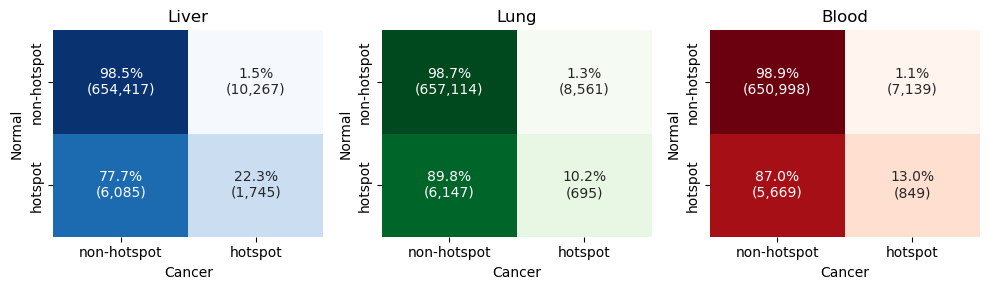

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(10,3))

# define colormap per tissue
cmap_dict = {
    "liver": "Blues",
    "lung": "Greens",
    "blood": "Reds"
}

for ax, (tissue, res) in zip(axes, results.items()):

    # build annotation: percentage (%) + count
    annot = res["prop_row"].copy().astype(str)

    for i in range(res["prop_row"].shape[0]):
        for j in range(res["prop_row"].shape[1]):
            p = res["prop_row"].iloc[i, j] * 100  # convert to %
            c = res["table"].iloc[i, j]          # raw count
            annot.iloc[i, j] = f"{p:.1f}%\n({c:,})"

    sns.heatmap(
        res["prop_row"],
        annot=annot,
        fmt="",
        cmap=cmap_dict[tissue],
        vmin=0,
        vmax=1,
        cbar=False,
        ax=ax
    )

    ax.set_title(tissue.capitalize())
    ax.set_xlabel("Cancer")
    ax.set_ylabel("Normal")

plt.tight_layout()
plt.show()

#### Among LTRs that are hotspots in normal and become non-hotspot in cancer, what chromatin state category do they resolve into?

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load
df_features = pd.read_csv("../processed/ltr_feature_table.csv")
df_seq = pd.read_csv("../processed/ltr_sequences.csv")

# merge
df = df_features.merge(
    df_seq,
    on=["cell_id", "is_cancer", "chrom", "start", "end", "name"],
    how="inner"
)

print(df.shape)

(85363427, 29)


In [95]:
df["is_hotspot"] = df["n_transitions"] >= 4

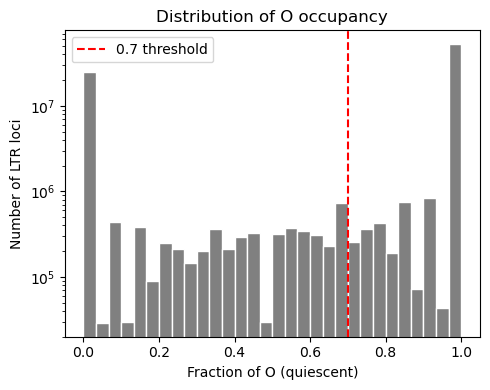

In [191]:
# overall distribution of O ratio

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.hist(df["O_ratio"], bins=30, color="gray", edgecolor="white", log=True)
plt.axvline(0.7, color="red", linestyle="--", label="0.7 threshold")

plt.xlabel("Fraction of O (quiescent)")
plt.ylabel("Number of LTR loci")
plt.title("Distribution of O occupancy")

plt.legend()
plt.tight_layout()
plt.show()

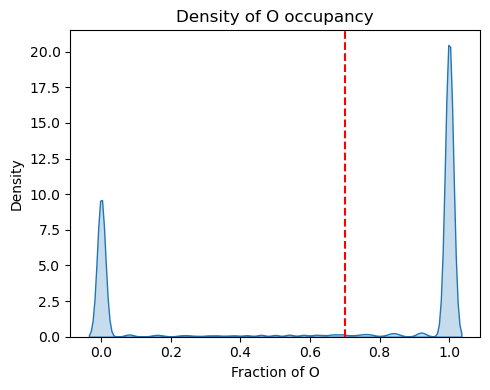

In [192]:
plt.figure(figsize=(5,4))

sns.kdeplot(data=df, x="O_ratio", fill=True)

plt.axvline(0.7, color="red", linestyle="--")

plt.xlabel("Fraction of O")
plt.title("Density of O occupancy")

plt.tight_layout()
plt.show()

In [196]:
# active_states = set("ABCDEFG")
# repressed_states = set("HIMN")
# # # repressed_states = set("HIMNO")
# bivalent_states = set("JKL")

# def classify_state_category(seq):
#     if pd.isna(seq) or len(seq) == 0:
#         return np.nan
    
#     # Check if O-only
#     if set(seq) == {"O"}:
#         return "Quiescent"
    
#     # Remove O for classification
#     seq = [ch for ch in seq if ch != "O"]
    
#     if len(seq) == 0:
#         return "Quiescent"
    
#     total = len(seq)
    
#     frac_active = sum(ch in active_states for ch in seq) / total
#     frac_repressed = sum(ch in repressed_states for ch in seq) / total
#     frac_bivalent = sum(ch in bivalent_states for ch in seq) / total
    
#     if frac_active > 0.5:
#         return "Active"
#     elif frac_repressed > 0.5:
#         return "Repressed"
#     elif frac_bivalent > 0.5:
#         return "Bivalent"
#     else:
#         return "Mixed"

active_states = set("ABCDEFG")
repressed_states = set("HIMN")
# # repressed_states = set("HIMNO")
bivalent_states = set("JKL")

def classify_state_category(seq):
    if pd.isna(seq) or len(seq) == 0:
        return np.nan
    
    total = len(seq)
    
    frac_O = seq.count("O") / total
    
    # 🥇 Step 1: quiescent filter
    if frac_O > 0.6:   # you can tune 0.6–0.8
        return "Quiescent"
    
    # 🥈 Step 2: compute fractions (including O in denominator)
    frac_active = sum(ch in active_states for ch in seq) / total
    frac_repressed = sum(ch in repressed_states for ch in seq) / total
    frac_bivalent = sum(ch in bivalent_states for ch in seq) / total
    
    if frac_active > 0.5:
        return "Active"
    elif frac_repressed > 0.5:
        return "Repressed"
    elif frac_bivalent > 0.5:
        return "Bivalent"
    else:
        return "Mixed"

In [197]:
df["state_category"] = df["state_seq_full_slice"].apply(classify_state_category)

In [198]:
df.tail(100)

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O,state_seq_full_slice,is_hotspot,state_category
85363327,E129,True,chrY,24582681,24585035,MER61-int,2354,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOO,False,Quiescent
85363328,E129,True,chrY,24583128,24587734,MER61-int,4606,24,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOOOOOOOOOOOOO,False,Quiescent
85363329,E129,True,chrY,24608476,24610995,LTR22,2519,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOO,False,Quiescent
85363330,E129,True,chrY,24651257,24654351,MER11B,3094,16,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOOOOO,False,Quiescent
85363331,E129,True,chrY,24661957,24664113,LTR32,2156,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOO,False,Quiescent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,E129,True,chrY,25239006,25241335,MER66-int,2329,12,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIII,False,Repressed
85363423,E129,True,chrY,25239335,25241651,MER66B,2316,13,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIIII,False,Repressed
85363424,E129,True,chrY,25239698,25242327,LTR12D,2629,14,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIIIII,False,Repressed
85363425,E129,True,chrY,25240331,25242491,LTR12D,2160,12,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIII,False,Repressed


In [199]:
df_partial_O = df[
    df["state_seq_full_slice"].str.contains("O", na=False) &
    (df["state_seq_full_slice"].str.replace("O", "", regex=False).str.len() > 0)
]

In [200]:
df_partial_O

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O,state_seq_full_slice,is_hotspot,state_category
117,E001,False,chr1,407238,409396,MLT1I,2158,11,0.909091,2,...,0.090909,0.0000,0.0,0.0,0.00,0.0,0.909091,OOOIOOOOOOO,False,Quiescent
118,E001,False,chr1,407459,409522,MLT1I,2063,11,0.909091,2,...,0.090909,0.0000,0.0,0.0,0.00,0.0,0.909091,OOIOOOOOOOO,False,Quiescent
162,E001,False,chr1,598078,600158,MLT1F1,2080,11,0.727273,1,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.727273,OOOOOOOOAAA,False,Quiescent
166,E001,False,chr1,615790,617961,MLT1K,2171,12,0.916667,1,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.916667,OOOOOOOOOOOG,False,Quiescent
167,E001,False,chr1,616973,619322,MER4E1,2349,13,0.384615,3,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.384615,OOOOOGGGEEGGG,False,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85361300,E129,True,chrY,17518775,17521733,PRIMA41-int,2958,16,0.687500,2,...,0.000000,0.0625,0.0,0.0,0.25,0.0,0.687500,MMMMJOOOOOOOOOOO,False,Quiescent
85363387,E129,True,chrY,25086531,25089107,LTR22,2576,14,0.928571,2,...,0.071429,0.0000,0.0,0.0,0.00,0.0,0.928571,OOOOOOOOIOOOOO,False,Quiescent
85363388,E129,True,chrY,25087109,25089782,HERVK22-int,2673,14,0.928571,2,...,0.071429,0.0000,0.0,0.0,0.00,0.0,0.928571,OOOOOIOOOOOOOO,False,Quiescent
85363389,E129,True,chrY,25088189,25091989,HERVK22-int,3800,20,0.950000,1,...,0.050000,0.0000,0.0,0.0,0.00,0.0,0.950000,IOOOOOOOOOOOOOOOOOOO,False,Quiescent


In [201]:
pairs = {
    "Liver": ("E066", "E118"),
    "Lung": ("E096", "E114"),
    "Blood": ("E029", "E123"),
}

In [202]:
records = []

for tissue, (normal_id, cancer_id) in pairs.items():
    df_normal = (
        df[df["cell_id"] == normal_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_normal",
            "state_category": "category_normal"
        })
    )

    df_cancer = (
        df[df["cell_id"] == cancer_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_cancer",
            "state_category": "category_cancer"
        })
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    # keep only resolving hotspots
    resolving = merged[
        (merged["hotspot_normal"] == True) &
        (merged["hotspot_cancer"] == False)
    ].copy()

    resolving["tissue"] = tissue
    records.append(resolving)

df_resolving = pd.concat(records, ignore_index=True)
print(df_resolving.shape)
df_resolving.head()

(17901, 9)


,chrom,start,end,name,hotspot_normal,category_normal,hotspot_cancer,category_cancer,tissue
0,chr1,732909,735062,LTR41,True,Active,False,Active,Liver
1,chr1,887956,890347,MSTD,True,Active,False,Active,Liver
2,chr1,888927,890998,MLT1I,True,Active,False,Active,Liver
3,chr1,1171049,1173409,MLT1D,True,Active,False,Bivalent,Liver
4,chr1,2351202,2353368,MLT1J,True,Active,False,Active,Liver


In [203]:
fate_counts = (
    df_resolving.groupby(["tissue", "category_cancer"])
    .size()
    .reset_index(name="count")
)

print(fate_counts)

   tissue category_cancer  count
0   Blood          Active   2998
1   Blood        Bivalent      1
2   Blood           Mixed    122
3   Blood       Quiescent   1554
4   Blood       Repressed    994
5   Liver          Active   3168
6   Liver        Bivalent    367
7   Liver           Mixed    277
8   Liver       Quiescent   1129
9   Liver       Repressed   1144
10   Lung          Active   2897
11   Lung        Bivalent     91
12   Lung           Mixed    147
13   Lung       Quiescent   1871
14   Lung       Repressed   1141


In [204]:
fate_props = fate_counts.copy()
fate_props["fraction"] = fate_props.groupby("tissue")["count"].transform(lambda x: x / x.sum())

print(fate_props)

   tissue category_cancer  count  fraction
0   Blood          Active   2998  0.528841
1   Blood        Bivalent      1  0.000176
2   Blood           Mixed    122  0.021521
3   Blood       Quiescent   1554  0.274122
4   Blood       Repressed    994  0.175340
5   Liver          Active   3168  0.520624
6   Liver        Bivalent    367  0.060312
7   Liver           Mixed    277  0.045522
8   Liver       Quiescent   1129  0.185538
9   Liver       Repressed   1144  0.188003
10   Lung          Active   2897  0.471287
11   Lung        Bivalent     91  0.014804
12   Lung           Mixed    147  0.023914
13   Lung       Quiescent   1871  0.304376
14   Lung       Repressed   1141  0.185619


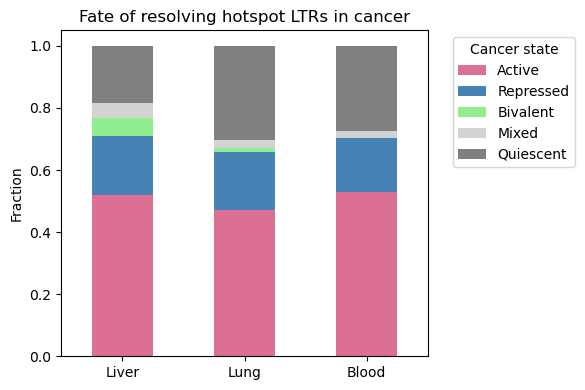

In [262]:
category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

plot_df = (
    fate_props.pivot(index="tissue", columns="category_cancer", values="fraction")
    .reindex(columns=category_order)
    .fillna(0)
)

color_dict = {
    "Active": "palevioletred",     # 
    "Repressed": "steelblue",  # 
    "Bivalent": "lightgreen",   # 
    "Mixed": "lightgray",   #
    "Quiescent": "gray"       # 
}

plot_df = plot_df.reindex(["Liver", "Lung", "Blood"])

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4),
    color=[color_dict[c] for c in plot_df.columns]
)

plt.ylabel("Fraction")
plt.xlabel("")
plt.title("Fate of resolving hotspot LTRs in cancer")

plt.xticks(rotation=0)  # cleaner for slides

plt.legend(title="Cancer state", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [207]:
summary_table = fate_counts.merge(
    fate_props[["tissue", "category_cancer", "fraction"]],
    on=["tissue", "category_cancer"]
)

summary_table["percent"] = summary_table["fraction"] * 100
print(summary_table.sort_values(["tissue", "category_cancer"]))

   tissue category_cancer  count  fraction    percent
0   Blood          Active   2998  0.528841  52.884107
1   Blood        Bivalent      1  0.000176   0.017640
2   Blood           Mixed    122  0.021521   2.152055
3   Blood       Quiescent   1554  0.274122  27.412242
4   Blood       Repressed    994  0.175340  17.533957
5   Liver          Active   3168  0.520624  52.062449
6   Liver        Bivalent    367  0.060312   6.031224
7   Liver           Mixed    277  0.045522   4.552177
8   Liver       Quiescent   1129  0.185538  18.553821
9   Liver       Repressed   1144  0.188003  18.800329
10   Lung          Active   2897  0.471287  47.128681
11   Lung        Bivalent     91  0.014804   1.480397
12   Lung           Mixed    147  0.023914   2.391410
13   Lung       Quiescent   1871  0.304376  30.437612
14   Lung       Repressed   1141  0.185619  18.561900


In [ ]:
# restrict to the same 3 normal tissues
normal_ids = ["E066", "E096", "E029"]  # liver, lung, blood

df_normal_subset = df[
    (df["is_cancer"] == False) &
    (df["cell_id"].isin(normal_ids))
]

# background
bg_counts = df_normal_subset["state_category"].value_counts()
bg_frac = bg_counts / bg_counts.sum()

# resolving (normal side)
res_counts = df_resolving["category_normal"].value_counts()
res_frac = res_counts / res_counts.sum()

# enrichment
enrichment = (res_frac / bg_frac).apply(np.log2)
print(enrichment)

Active       1.801779
Bivalent     5.048741
Mixed        2.132036
Quiescent   -3.183279
Repressed   -0.529284
Name: count, dtype: float64


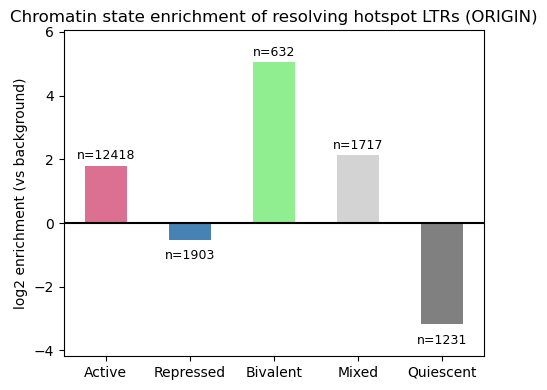

In [257]:
# make sure order is consistent
enrichment = enrichment.reindex(["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"])
res_counts = res_counts.reindex(enrichment.index)  # align counts

plt.figure(figsize=(5,4))

ax = enrichment.plot(
    kind="bar",
    color=[
        "palevioletred",  # Active
        "steelblue",      # Repressed
        "lightgreen",     # Bivalent
        "lightgray",      # Mixed
        "gray"            # Quiescent
    ]
)

plt.axhline(0, color="black")

plt.ylabel("log2 enrichment (vs background)")
plt.ylim(enrichment.min() - 1, enrichment.max() + 1)
plt.title("Chromatin state enrichment of resolving hotspot LTRs (ORIGIN)")

plt.xticks(rotation=0)

# add count labels
for i, (val, cnt) in enumerate(zip(enrichment, res_counts)):
    ax.text(
        i,
        val + (0.1 if val >= 0 else -0.3),  # position above/below bar
        f"n={cnt}",
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Why 4 as a threshold for hotspot definition


In [64]:
import numpy as np
import pandas as pd

thresholds = [2, 3, 4, 5, 6]

records = []

for tissue, (normal_id, cancer_id) in pairs.items():
    df_n = df[df["cell_id"] == normal_id].copy()
    df_c = df[df["cell_id"] == cancer_id].copy()

    merged = df_n.merge(
        df_c,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )

    for t in thresholds:
        merged["hotspot_normal"] = merged["n_transitions_normal"] >= t
        merged["hotspot_cancer"] = merged["n_transitions_cancer"] >= t

        sub = merged[merged["hotspot_normal"] == True]

        if len(sub) == 0:
            continue

        frac_resolve = (sub["hotspot_cancer"] == False).mean()
        frac_persist = (sub["hotspot_cancer"] == True).mean()

        records.append({
            "tissue": tissue,
            "threshold": t,
            "resolve": frac_resolve,
            "persist": frac_persist
        })

df_robust = pd.DataFrame(records)

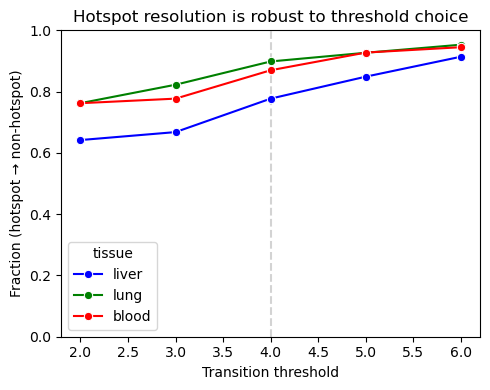

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "liver": "blue",
    "lung": "green",
    "blood": "red"
}

plt.figure(figsize=(5,4))
plt.axvline(4, linestyle="--", color="lightgray")

sns.lineplot(
    data=df_robust,
    x="threshold",
    y="resolve",
    hue="tissue",
    marker="o",
    palette=palette 
)

plt.ylabel("Fraction (hotspot → non-hotspot)")
plt.xlabel("Transition threshold")
plt.title("Hotspot resolution is robust to threshold choice")

plt.ylim(0,1)
plt.tight_layout()
plt.show()

Highly dynamic (high-transition) chromatin regions are intrinsically unstable and preferentially collapse into more stable states in cancer.


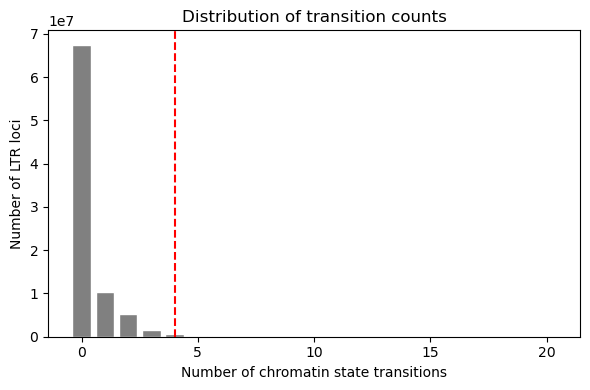

In [93]:
counts = df["n_transitions"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.axvline(4, color="red", linestyle="--")

plt.bar(counts.index, counts.values, color="gray", edgecolor="white")

plt.xlabel("Number of chromatin state transitions")
plt.ylabel("Number of LTR loci")
plt.title("Distribution of transition counts")

plt.tight_layout()
plt.show()

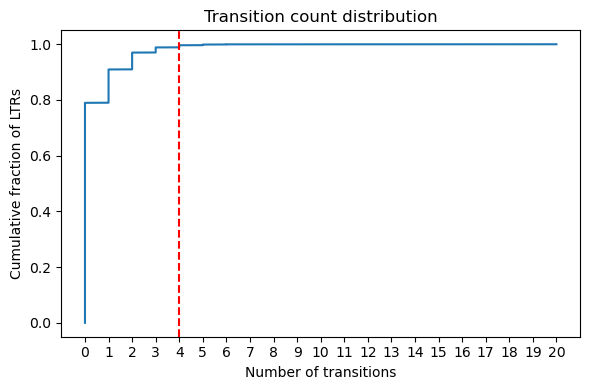

In [92]:
import numpy as np

sorted_vals = np.sort(df["n_transitions"])
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.figure(figsize=(6,4))
plt.plot(sorted_vals, cdf)

plt.axvline(4, color="red", linestyle="--")

plt.xlabel("Number of transitions")
plt.xticks(range(0, df["n_transitions"].max()+1))
plt.ylabel("Cumulative fraction of LTRs")
plt.title("Transition count distribution")

plt.tight_layout()
plt.show()